# Phase 6 — Grad-CAM Explainability
Visualize image regions influencing OK and Defective predictions.

Explainability matters because inspectors need evidence, not only a label. Heatmaps can reveal whether the model focuses on a casting surface region or on irrelevant background, supporting safer review and manufacturing decisions.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
root=Path.cwd(); pred_df=pd.read_csv(root/'phase4_test_predictions.csv'); labels=pd.read_csv(root/'phase2_clean_splits.csv')[['path','label']]; pred_df=pred_df.merge(labels,on='path',how='left')
model=models.mobilenet_v2(weights=None); model.classifier[1]=torch.nn.Linear(model.last_channel,2)
model.load_state_dict(torch.load(root/'phase6_selected_model.pt',map_location='cpu')); model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

## Define Grad-CAM
The final convolutional block provides spatial activations and gradients.

In [2]:
mean,std=np.array([.485,.456,.406]),np.array([.229,.224,.225]); tf=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(mean,std)])
activations, gradients = {}, {}
layer=model.features[-1]
layer.register_forward_hook(lambda m,i,o: activations.update(value=o))
layer.register_full_backward_hook(lambda m,gi,go: gradients.update(value=go[0]))
print('Grad-CAM hooks registered on MobileNetV2 final feature block.')

Grad-CAM hooks registered on MobileNetV2 final feature block.


## Generate one heatmap
The heatmap is normalized and overlaid on the original image.

In [3]:
def gradcam(path):
    model.zero_grad(); image=Image.open(path).convert('RGB'); x=tf(image).unsqueeze(0); x.requires_grad_()
    out=model(x); cls=int(out.argmax(1)); out[0,cls].backward()
    a,g=activations['value'][0],gradients['value'][0]; cam=torch.relu((g.mean((1,2),keepdim=True)*a).sum(0)).detach().numpy()
    cam=(cam-cam.min())/(cam.max()-cam.min()+1e-8); heat=Image.fromarray(np.uint8(cam*255)).resize(image.size); return image,cls,float(out.softmax(1)[0,cls]),np.asarray(heat)/255.0

## Select correct and incorrect cases
Examples come directly from Phase 4 predictions, including false positives and false negatives.

Correct           2
False positive    1
False negative    1
Name: case, dtype: int64


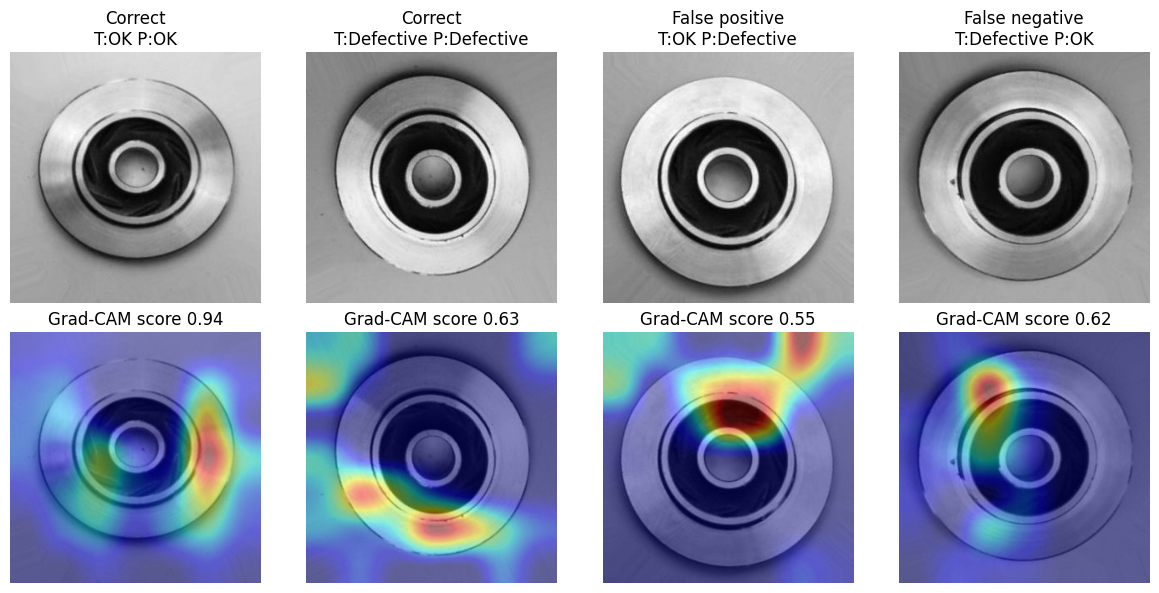

In [4]:
correct=pred_df[pred_df.case.eq('Correct')].head(2); fp=pred_df[pred_df.case.eq('False positive')].head(1); fn=pred_df[pred_df.case.eq('False negative')].head(1)
cases=pd.concat([correct,fp,fn],ignore_index=True); print(cases.case.value_counts())
fig,axes=plt.subplots(2,4,figsize=(12,6))
for col,(_,r) in enumerate(cases.iterrows()):
    image,cls,score,heat=gradcam(r['path']); axes[0,col].imshow(image); axes[0,col].set_title(f"{r['case']}\nT:{r['label']} P:{'Defective' if r['predicted'] else 'OK'}"); axes[0,col].axis('off')
    axes[1,col].imshow(image); axes[1,col].imshow(heat,cmap='jet',alpha=.45); axes[1,col].set_title(f'Grad-CAM score {score:.2f}'); axes[1,col].axis('off')
plt.tight_layout(); plt.savefig('phase6_gradcam_examples.png',dpi=160); plt.show()

## Save explanation metadata
The CSV links each displayed case to its true and predicted label.

In [5]:
cases.to_csv('phase6_gradcam_cases.csv',index=False)
print('Saved Grad-CAM examples and case metadata.')
print('Phase 6 complete; continuing to Phase 7.')

Saved Grad-CAM examples and case metadata.
Phase 6 complete; continuing to Phase 7.
